# RQ3 Part 2 — Payment Gap Prediction
### DSCI 5260 — Group 6 | Medicare Inpatient Utilization and Payment Analysis

---

**Motivation:**  
Part 1 predicted raw Medicare payment amounts (`Avg_Mdcr_Pymt_Amt`), where DRG Weight dominated feature importance — an expected outcome given that DRG Weight is structurally embedded in CMS payment formulas.  

Part 2 shifts the target to the **Payment Gap** — the difference between what hospitals bill and what Medicare actually pays. This target is not mechanically determined by DRG Weight alone, and allows hospital-level factors (ownership, geography, size) to express more explanatory power.

**Research Question:**  
> Which hospital and diagnosis characteristics best explain the gap between billed charges and Medicare reimbursements?

---
## 5.1 Variable Definitions

### Dependent Variable (Target)

| Variable | Raw Column | Model Column | Description |
|----------|------------|--------------|-------------|
| Payment Gap | `Avg_Submtd_Cvrd_Chrg - Avg_Mdcr_Pymt_Amt` | `Log_Payment_Gap` | Log-transformed gap between billed charges and Medicare payment |

### Independent Variables (Features)

| Variable | Column | Description |
|----------|--------|-------------|
| Diagnosis Severity | `DRG_Weight` | CMS complexity weight for each DRG |
| Hospital Size | `BED_CNT` | Number of licensed beds |
| Volume | `Log_Tot_Dschrgs` | Log-transformed total discharges |
| Ownership (For-Profit) | `own_For-Profit` | 1 if for-profit vs Government (reference) |
| Ownership (Non-Profit) | `own_Non-Profit` | 1 if non-profit vs Government (reference) |
| Geography (Metro) | `ruca_Metropolitan` | 1 if metropolitan vs Rural (reference) |
| Geography (Micro) | `ruca_Micropolitan` | 1 if micropolitan vs Rural (reference) |
| Geography (Small Town) | `ruca_Small Town` | 1 if small town vs Rural (reference) |
| Year | `Data_Year` | Fiscal year (2017–2023) |
| Outlier Flag | `outlier_payment_flag` | 1 if case was flagged as a payment outlier |

---
## 5.2 Load Data & Engineer Target Variable

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

PROCESSED_DIR = Path('..') / 'Data' / 'Processed_Data'

df_train = pd.read_parquet(PROCESSED_DIR / 'df_train.parquet')
df_val   = pd.read_parquet(PROCESSED_DIR / 'df_val.parquet')
df_test  = pd.read_parquet(PROCESSED_DIR / 'df_test.parquet')

print(f'Train:      {len(df_train):>8,}')
print(f'Validation: {len(df_val):>8,}')
print(f'Test:       {len(df_test):>8,}')

Train:       820,547
Validation:  175,832
Test:        175,832


=== Payment Gap Distribution ===
count      $820,547.00
mean        $61,531.43
std         $82,181.10
min       $-107,877.07
25%         $21,563.51
50%         $38,709.57
75%         $71,613.77
max      $5,262,635.27
Name: Payment_Gap, dtype: object

Negative gaps (train): 1048
Zero gaps (train):     0


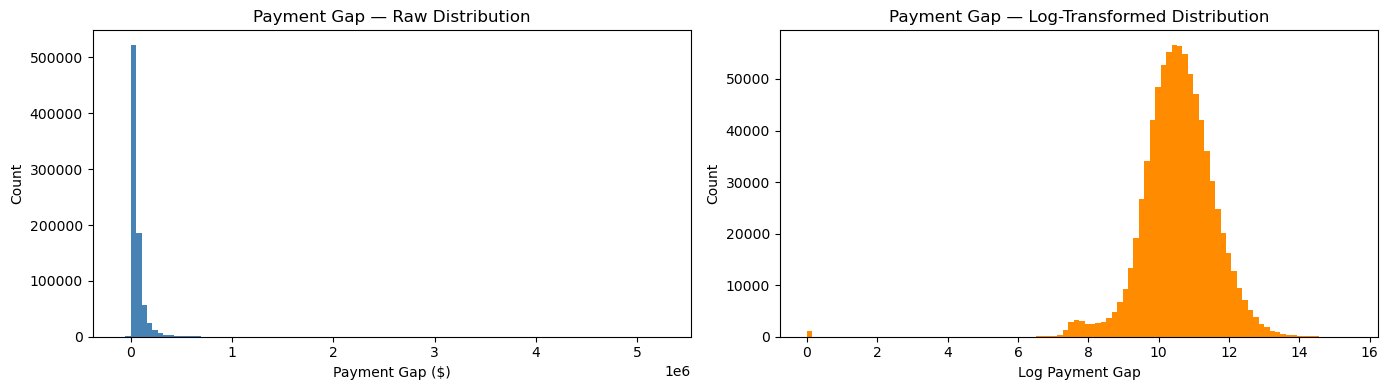


Log Payment Gap — Mean : 10.5554
Log Payment Gap — Std  : 1.0364
Mean gap (original $)  : $38,383


In [3]:
# ── Engineer Payment Gap target variable ──
for df in [df_train, df_val, df_test]:
    df['Payment_Gap'] = df['Avg_Submtd_Cvrd_Chrg'] - df['Avg_Mdcr_Pymt_Amt']

# Check for negative or zero gaps before log-transforming
print('=== Payment Gap Distribution ===')
print(df_train['Payment_Gap'].describe().apply(lambda x: f'${x:,.2f}'))
print(f'\nNegative gaps (train): {(df_train["Payment_Gap"] < 0).sum()}')
print(f'Zero gaps (train):     {(df_train["Payment_Gap"] == 0).sum()}')

# Plot raw distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_train['Payment_Gap'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Payment Gap — Raw Distribution')
axes[0].set_xlabel('Payment Gap ($)')
axes[0].set_ylabel('Count')

# Log-transform (use log1p to handle zeros safely)
for df in [df_train, df_val, df_test]:
    df['Log_Payment_Gap'] = np.log1p(df['Payment_Gap'].clip(lower=0))

axes[1].hist(df_train['Log_Payment_Gap'], bins=100, color='darkorange', edgecolor='none')
axes[1].set_title('Payment Gap — Log-Transformed Distribution')
axes[1].set_xlabel('Log Payment Gap')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'\nLog Payment Gap — Mean : {df_train["Log_Payment_Gap"].mean():.4f}')
print(f'Log Payment Gap — Std  : {df_train["Log_Payment_Gap"].std():.4f}')
print(f'Mean gap (original $)  : ${np.expm1(df_train["Log_Payment_Gap"].mean()):,.0f}')

In [4]:
# ── Define RQ3 Part 2 feature set and target ──
RQ3P2_TARGET = 'Log_Payment_Gap'

RQ3P2_FEATURES = [
    # Diagnosis severity
    'DRG_Weight',
    # Hospital characteristics
    'BED_CNT',
    'Log_Tot_Dschrgs',
    'own_For-Profit',        # vs Government (reference — dropped to avoid dummy variable trap)
    'own_Non-Profit',        # vs Government (reference — dropped to avoid dummy variable trap)
    # own_Government ← reference category DROPPED
    # Geographic factors
    'ruca_Metropolitan',     # vs Rural (reference — dropped to avoid dummy variable trap)
    'ruca_Micropolitan',     # vs Rural (reference — dropped to avoid dummy variable trap)
    'ruca_Small Town',       # vs Rural (reference — dropped to avoid dummy variable trap)
    # ruca_Rural ← reference category DROPPED
    # Temporal
    'Data_Year',
    # Payment type
    'outlier_payment_flag'
]

X_train = df_train[RQ3P2_FEATURES]
y_train = df_train[RQ3P2_TARGET]

X_val   = df_val[RQ3P2_FEATURES]
y_val   = df_val[RQ3P2_TARGET]

X_test  = df_test[RQ3P2_FEATURES]
y_test  = df_test[RQ3P2_TARGET]

print(f'Features ({len(RQ3P2_FEATURES)}): {RQ3P2_FEATURES}')
print(f'\nReference categories (baseline for interpretation):')
print(f'  Ownership : own_Government')
print(f'  Geography : ruca_Rural')
print(f'\nTarget : {RQ3P2_TARGET}')
print(f'  Mean : {y_train.mean():.4f}')
print(f'  Std  : {y_train.std():.4f}')
print(f'  Range: [{y_train.min():.3f}, {y_train.max():.3f}]')
print(f'\n  Mean payment gap (original scale): ${np.expm1(y_train.mean()):,.0f}')

Features (10): ['DRG_Weight', 'BED_CNT', 'Log_Tot_Dschrgs', 'own_For-Profit', 'own_Non-Profit', 'ruca_Metropolitan', 'ruca_Micropolitan', 'ruca_Small Town', 'Data_Year', 'outlier_payment_flag']

Reference categories (baseline for interpretation):
  Ownership : own_Government
  Geography : ruca_Rural

Target : Log_Payment_Gap
  Mean : 10.5554
  Std  : 1.0364
  Range: [0.000, 15.476]

  Mean payment gap (original scale): $38,383


---
## 5.3 Shared Evaluation Helper

In [5]:
# ── Shared evaluation helper ──
def evaluate(name, model, X, y, split='Val'):
    preds   = model.predict(X)
    rmse    = np.sqrt(mean_squared_error(y, preds))
    mae     = mean_absolute_error(y, preds)
    r2      = r2_score(y, preds)

    # Back-transform from log to dollars
    y_dollars    = np.expm1(np.array(y))
    pred_dollars = np.expm1(preds)

    # MAE in dollars
    mae_usd = np.mean(np.abs(y_dollars - pred_dollars))

    # MAPE — exclude zero-gap rows (MAPE undefined when actual = 0)
    nonzero_mask = y_dollars > 0
    mape = np.mean(np.abs(
        (y_dollars[nonzero_mask] - pred_dollars[nonzero_mask]) / y_dollars[nonzero_mask]
    )) * 100

    print(f'[{split}] {name:25s}  RMSE: {rmse:.4f}   MAE (log): {mae:.4f}   '
          f'MAE ($): ${mae_usd:,.0f}   MAPE: {mape:.1f}%   R²: {r2:.4f}')

    return {
        'Model':   name,
        'Split':   split,
        'RMSE':    round(rmse, 4),
        'MAE':     round(mae, 4),
        'MAE_USD': round(mae_usd, 2),
        'MAPE':    round(mape, 2),
        'R2':      round(r2, 4)
    }

results = []

---
## 5.4 Step 1 — Baseline Model: Linear Regression

Establishes a minimum benchmark. Captures only linear relationships between features and payment gap.

In [6]:
# ── Scale features for Linear Regression ──
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

results.append(evaluate('Linear Regression', lr, X_train_sc, y_train, 'Train'))
results.append(evaluate('Linear Regression', lr, X_val_sc,   y_val,   'Val'))

[Train] Linear Regression          RMSE: 0.7450   MAE (log): 0.5429   MAE ($): $163,356   MAPE: 110.9%   R²: 0.4832
[Val] Linear Regression          RMSE: 0.7451   MAE (log): 0.5416   MAE ($): $214,924   MAPE: 127.9%   R²: 0.4901


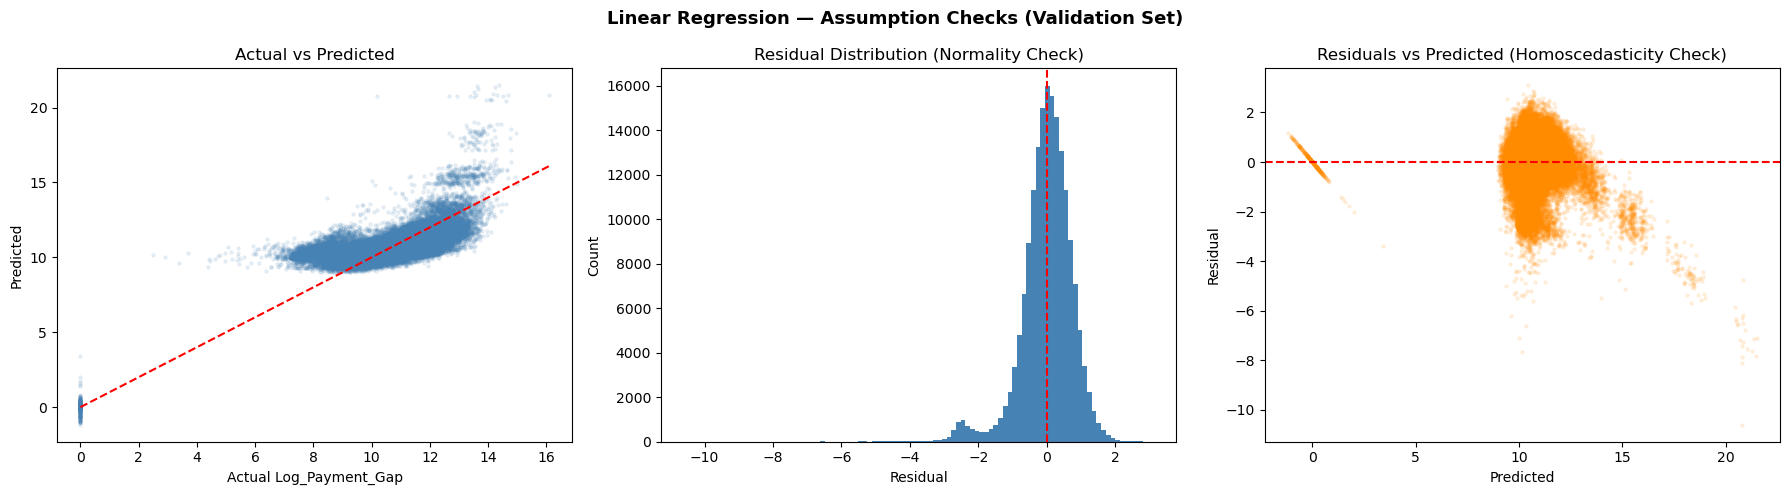

In [7]:
# ── Linear Regression assumption checks ──
lr_preds_val = lr.predict(X_val_sc)
lr_residuals = y_val.values - lr_preds_val

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Linear Regression — Assumption Checks (Validation Set)', fontsize=13, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_val, lr_preds_val, alpha=0.1, s=5, color='steelblue')
mn, mx = y_val.min(), y_val.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Log_Payment_Gap')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

# Residual distribution
axes[1].hist(lr_residuals, bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution (Normality Check)')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

# Residuals vs Predicted
axes[2].scatter(lr_preds_val, lr_residuals, alpha=0.1, s=5, color='darkorange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Predicted (Homoscedasticity Check)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residual')

plt.tight_layout()
plt.show()

---
## 5.5 Step 2 — Random Forest Regressor

Captures non-linear relationships and feature interactions. No scaling required.

n= 50 | Val R²=0.5915
n=100 | Val R²=0.5915
n=150 | Val R²=0.5916
n=200 | Val R²=0.5913
n=250 | Val R²=0.5912
n=300 | Val R²=0.5910
n=350 | Val R²=0.5912


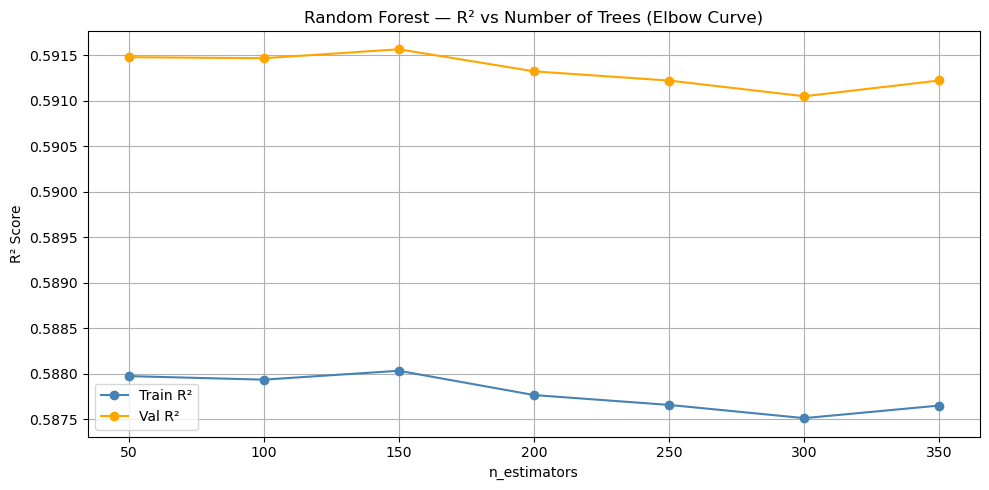


Optimal n_estimators: 150
[Train] Random Forest              RMSE: 0.6652   MAE (log): 0.4799   MAE ($): $26,090   MAPE: 75.4%   R²: 0.5880
[Val] Random Forest              RMSE: 0.6668   MAE (log): 0.4810   MAE ($): $26,361   MAPE: 73.7%   R²: 0.5916


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# ── Random Forest: elbow curve to find optimal n_estimators ──
estimator_range  = [50, 100, 150, 200, 250, 300, 350]
train_r2_scores  = []
val_r2_scores    = []

for n in estimator_range:
    _rf = RandomForestRegressor(
        n_estimators=n,
        max_depth=12,
        min_samples_leaf=20,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    _rf.fit(X_train, y_train)
    train_r2_scores.append(r2_score(y_train, _rf.predict(X_train)))
    val_r2_scores.append(r2_score(y_val,   _rf.predict(X_val)))
    print(f'n={n:>3} | Val R²={val_r2_scores[-1]:.4f}')

plt.figure(figsize=(10, 5))
plt.plot(estimator_range, train_r2_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(estimator_range, val_r2_scores,   marker='o', label='Val R²',   color='orange')
plt.xlabel('n_estimators')
plt.ylabel('R² Score')
plt.title('Random Forest — R² vs Number of Trees (Elbow Curve)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Refit with optimal n_estimators ──
best_n = estimator_range[int(np.argmax(val_r2_scores))]
print(f'\nOptimal n_estimators: {best_n}')

rf = RandomForestRegressor(
    n_estimators=best_n,
    max_depth=12,
    min_samples_leaf=20,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

results.append(evaluate('Random Forest', rf, X_train, y_train, 'Train'))
results.append(evaluate('Random Forest', rf, X_val,   y_val,   'Val'))

---
## 5.6 Step 3 — XGBoost Regressor

Gradient boosted trees with early stopping on the validation set.

In [9]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=2700,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.7,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse',
    verbosity=0,
    early_stopping_rounds=30
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration: {xgb_model.best_iteration}')
results.append(evaluate('XGBoost', xgb_model, X_train, y_train, 'Train'))
results.append(evaluate('XGBoost', xgb_model, X_val,   y_val,   'Val'))

Best iteration: 1628
[Train] XGBoost                    RMSE: 0.5618   MAE (log): 0.3996   MAE ($): $20,990   MAPE: 53.8%   R²: 0.7061
[Val] XGBoost                    RMSE: 0.5826   MAE (log): 0.4144   MAE ($): $22,003   MAPE: 57.7%   R²: 0.6883


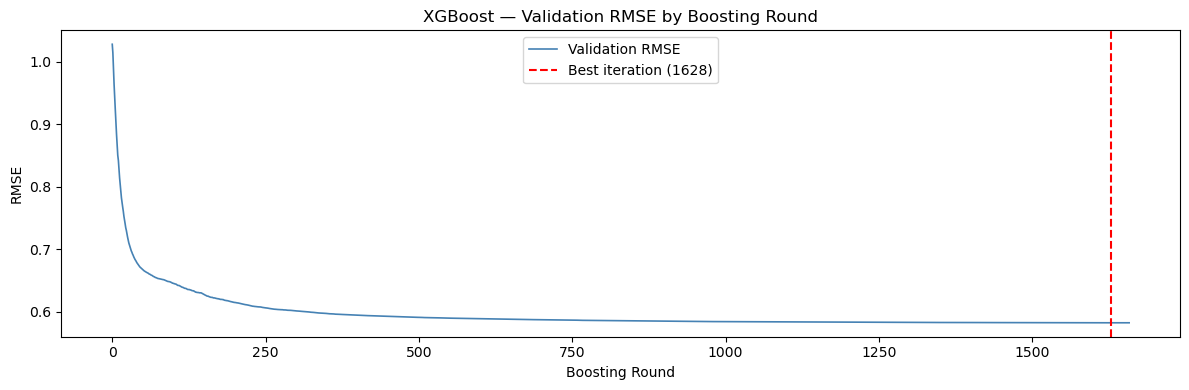

In [10]:
# ── XGBoost learning curve ──
evals_result = xgb_model.evals_result()
val_rmse     = evals_result['validation_0']['rmse']

plt.figure(figsize=(12, 4))
plt.plot(val_rmse, color='steelblue', linewidth=1.2, label='Validation RMSE')
plt.axvline(xgb_model.best_iteration, color='red', linestyle='--',
            label=f'Best iteration ({xgb_model.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE')
plt.title('XGBoost — Validation RMSE by Boosting Round')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5.7 Step 4 — Model Comparison (Validation Set)

In [11]:
results_df  = pd.DataFrame(results)
val_results = (results_df[results_df['Split'] == 'Val']
               .sort_values('R2', ascending=False)
               .reset_index(drop=True))

print('=== Validation Set Comparison ===')
print(val_results[['Model', 'RMSE', 'MAE', 'MAE_USD', 'MAPE', 'R2']].to_string(index=False))

=== Validation Set Comparison ===
            Model   RMSE    MAE   MAE_USD   MAPE     R2
          XGBoost 0.5826 0.4144  22002.64  57.67 0.6883
    Random Forest 0.6668 0.4810  26361.28  73.74 0.5916
Linear Regression 0.7451 0.5416 214924.32 127.92 0.4901


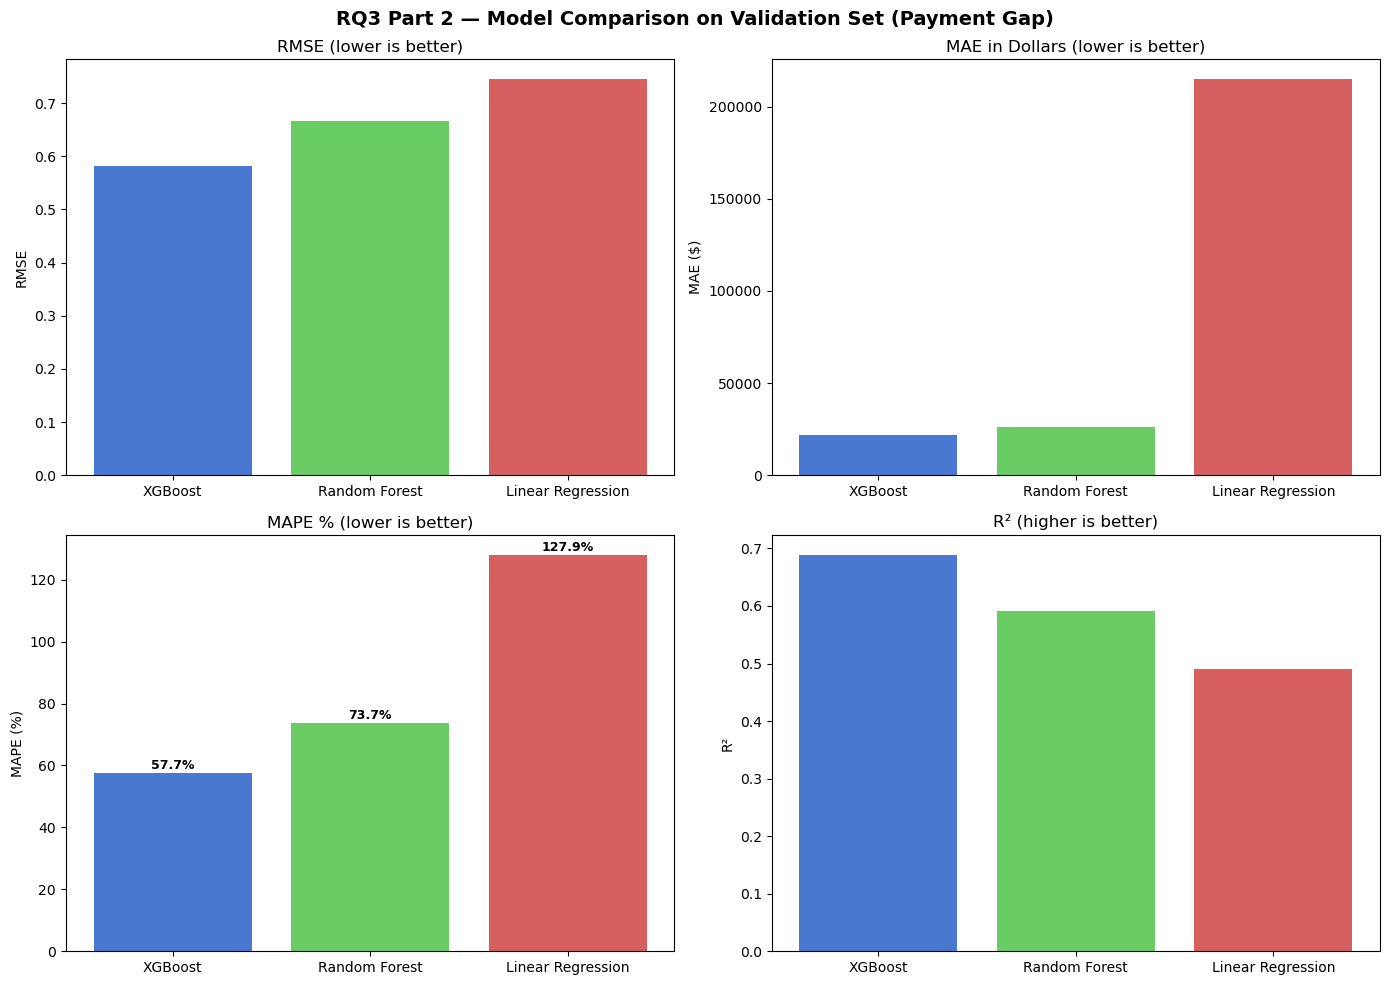

In [12]:
# ── Bar charts — 2 per row ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RQ3 Part 2 — Model Comparison on Validation Set (Payment Gap)', fontsize=14, fontweight='bold')

colors = ['#4878CF', '#6ACC65', '#D65F5F']
models = val_results['Model'].tolist()

axes[0, 0].bar(models, val_results['RMSE'], color=colors[:len(models)])
axes[0, 0].set_title('RMSE (lower is better)')
axes[0, 0].set_ylabel('RMSE')

axes[0, 1].bar(models, val_results['MAE_USD'], color=colors[:len(models)])
axes[0, 1].set_title('MAE in Dollars (lower is better)')
axes[0, 1].set_ylabel('MAE ($)')

axes[1, 0].bar(models, val_results['MAPE'], color=colors[:len(models)])
axes[1, 0].set_title('MAPE % (lower is better)')
axes[1, 0].set_ylabel('MAPE (%)')
for bar, val in zip(axes[1, 0].patches, val_results['MAPE']):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1, 1].bar(models, val_results['R2'], color=colors[:len(models)])
axes[1, 1].set_title('R² (higher is better)')
axes[1, 1].set_ylabel('R²')

plt.tight_layout()
plt.show()

---
## 5.8 Step 5 — Feature Importance

Compare built-in feature importance from Random Forest (MDI) and XGBoost (Gain).  
Key question: does ownership or geography become more important when predicting gap vs raw payment?

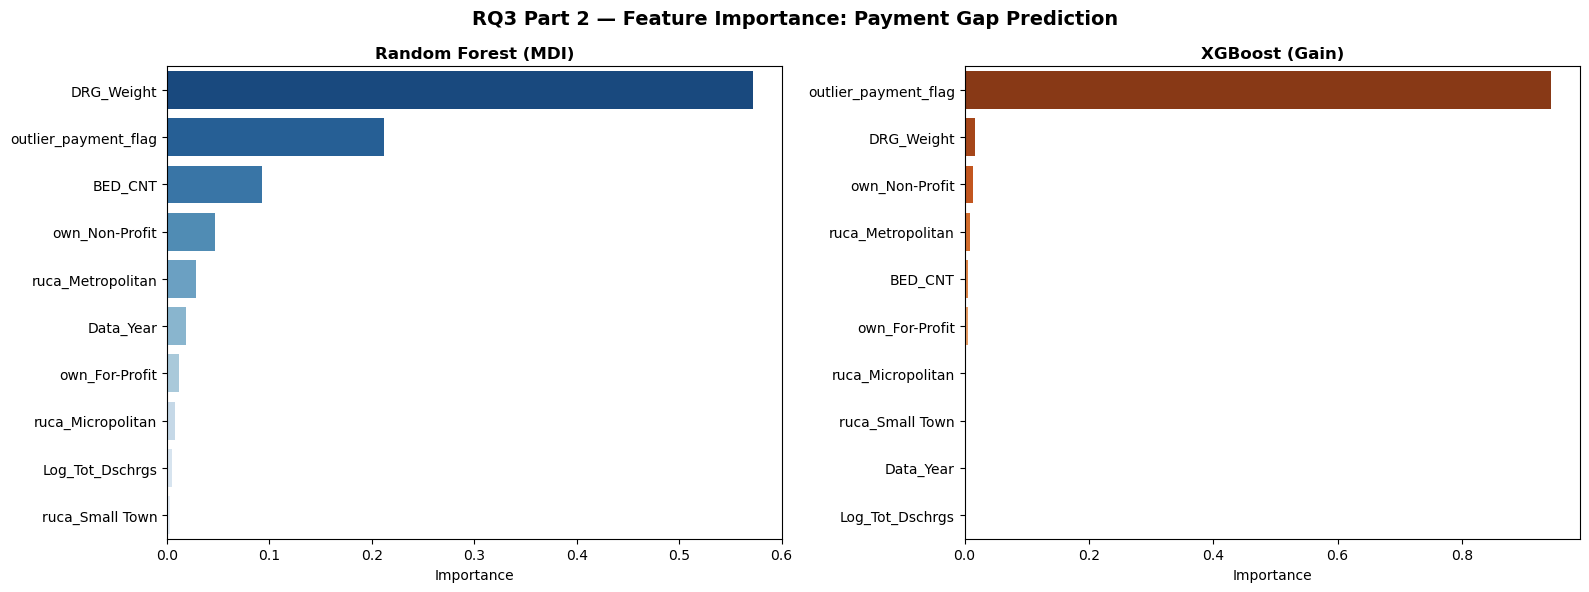

In [13]:
rf_imp  = pd.DataFrame({'Feature': RQ3P2_FEATURES, 'Importance': rf.feature_importances_,        'Model': 'Random Forest'})
xgb_imp = pd.DataFrame({'Feature': RQ3P2_FEATURES, 'Importance': xgb_model.feature_importances_, 'Model': 'XGBoost'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RQ3 Part 2 — Feature Importance: Payment Gap Prediction', fontsize=14, fontweight='bold')

for ax, imp_df, title, color in zip(
    axes,
    [rf_imp.sort_values('Importance', ascending=False),
     xgb_imp.sort_values('Importance', ascending=False)],
    ['Random Forest (MDI)', 'XGBoost (Gain)'],
    ['Blues_r', 'Oranges_r']
):
    sns.barplot(data=imp_df.sort_values('Importance', ascending=False),
                x='Importance', y='Feature', palette=color, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

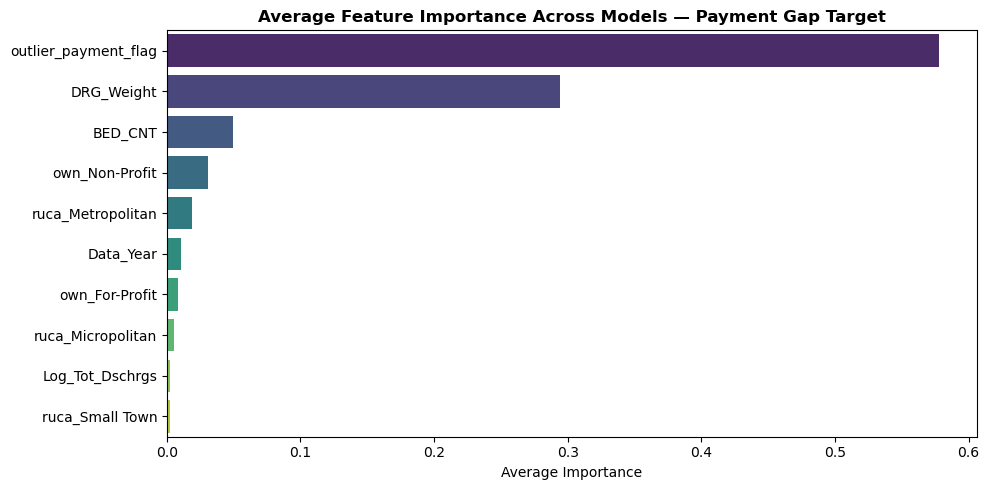


Average Feature Importance (RF + XGBoost):
             Feature  Avg_Importance
outlier_payment_flag        0.577605
          DRG_Weight        0.294312
             BED_CNT        0.049538
      own_Non-Profit        0.030467
   ruca_Metropolitan        0.018615
           Data_Year        0.010322
      own_For-Profit        0.008525
   ruca_Micropolitan        0.005338
     Log_Tot_Dschrgs        0.002706
     ruca_Small Town        0.002572


In [14]:
# ── Side-by-side importance comparison: Part 1 vs Part 2 ──
# Shows how feature rankings shift when target changes from payment amount to payment gap

combined = pd.concat([rf_imp, xgb_imp])
avg_imp  = (combined.groupby('Feature')['Importance']
            .mean()
            .sort_values(ascending=False)
            .reset_index())
avg_imp.columns = ['Feature', 'Avg_Importance']

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_imp, x='Avg_Importance', y='Feature', palette='viridis')
plt.title('Average Feature Importance Across Models — Payment Gap Target', fontweight='bold')
plt.xlabel('Average Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

print('\nAverage Feature Importance (RF + XGBoost):')
print(avg_imp.to_string(index=False))

---
## 5.9 Step 6 — Final Evaluation on Test Set

Run the best model **once** on the held-out test set. Selected based on validation R².

In [ ]:
# ── Select best model ──
best_model_name = val_results.iloc[0]['Model']
model_map = {
    'Linear Regression': (lr, X_test, scaler.transform(X_test)),
    'Random Forest':     (rf, X_test, None),
    'XGBoost':           (xgb_model, X_test, None)
}
best_model, X_test_use, X_test_scaled = model_map[best_model_name]
X_final = X_test_scaled if best_model_name == 'Linear Regression' else X_test_use

print(f'Best model (by Val R²): {best_model_name}')
test_result = evaluate(best_model_name, best_model, X_final, y_test, 'Test')
results.append(test_result)

In [ ]:
# ── Residual analysis — test set ──
y_pred_test = best_model.predict(X_final)
residuals   = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{best_model_name} — Test Set Diagnostics (Payment Gap)', fontsize=13, fontweight='bold')

axes[0].scatter(y_test, y_pred_test, alpha=0.1, s=5, color='steelblue')
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Log_Payment_Gap')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

axes[1].hist(residuals, bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

axes[2].scatter(y_pred_test, residuals, alpha=0.1, s=5, color='darkorange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals vs Predicted')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residual')

plt.tight_layout()
plt.show()

In [ ]:
# ── Error breakdown by ownership type and RUCA group ──
eval_df = df_test[['Ownership_Type', 'RUCA_Group']].copy()
eval_df['actual']    = y_test.values
eval_df['predicted'] = y_pred_test
eval_df['abs_error'] = np.abs(eval_df['actual'] - eval_df['predicted'])
eval_df['error_usd'] = np.expm1(eval_df['abs_error'])

# MAPE per row
actual_dollars   = np.expm1(eval_df['actual'])
pred_dollars_col = np.expm1(eval_df['predicted'])
eval_df['mape_row'] = np.where(
    actual_dollars > 0,
    np.abs((actual_dollars - pred_dollars_col) / actual_dollars) * 100,
    np.nan
)

print('=== MAE & MAPE by Ownership Type ===')
own_grp = eval_df.groupby('Ownership_Type').agg(
    MAE_log  = ('abs_error', 'mean'),
    MAE_usd  = ('error_usd', 'mean'),
    MAPE_pct = ('mape_row',  'mean')
).round(2)
print(own_grp.rename(columns={'MAE_log': 'MAE (log)', 'MAE_usd': 'MAE ($)', 'MAPE_pct': 'MAPE (%)'}))

print('\n=== MAE & MAPE by RUCA Group ===')
ruca_grp = eval_df.groupby('RUCA_Group').agg(
    MAE_log  = ('abs_error', 'mean'),
    MAE_usd  = ('error_usd', 'mean'),
    MAPE_pct = ('mape_row',  'mean')
).round(2)
print(ruca_grp.rename(columns={'MAE_log': 'MAE (log)', 'MAE_usd': 'MAE ($)', 'MAPE_pct': 'MAPE (%)'}))
print('\nNote: MAPE rows with $0 actual gap are excluded from group averages.')

In [ ]:
# ── Full results summary ──
final_df = pd.DataFrame(results)
print('=== RQ3 Part 2 Full Results Summary ===')
print(final_df[['Model', 'Split', 'RMSE', 'MAE', 'MAE_USD', 'MAPE', 'R2']].to_string(index=False))

---
## 5.10 Key Findings

> Update this section after running the notebook with actual results.

**Key questions to answer:**
- Did R² improve or decline compared to Part 1 (predicting raw payment)?
- Did DRG Weight remain dominant, or did ownership/geography move up in feature importance?
- Which ownership type has the highest prediction error on gap?
- Which RUCA group has the highest prediction error on gap?
- Does the model predict gap better for rural or urban hospitals?